# 🔬 GP Emulators — Hands-On Session
### Adapted from JETSCAPE Summer School 2021
_Bayesian Parameter Estimation for Relativistic Heavy-Ion Physics_

---

**Topics covered:**
1. Generating synthetic heavy-ion simulation data
2. Preprocessing: standardization & PCA
3. Building GP emulators (mean + uncertainty)
4. Validation of emulators
5. Full pipeline on realistic observables

> **Goal:** Replace expensive JETSCAPE simulations with fast, accurate Gaussian Process surrogate models.


## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern
from sklearn.metrics import r2_score

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

rng = np.random.default_rng(42)
print('✅ Setup complete')

✅ Setup complete


---
## Part I — Toy Problem: 1D GP Emulator from Scratch

Before tackling heavy-ion data, let's build intuition with a simple 1D problem.

**Setup:** We have an expensive "simulator" $f(x)$ that we want to emulate cheaply.

Optimized kernel: 1.09**2 * RBF(length_scale=0.707) + WhiteKernel(noise_level=1e-05)


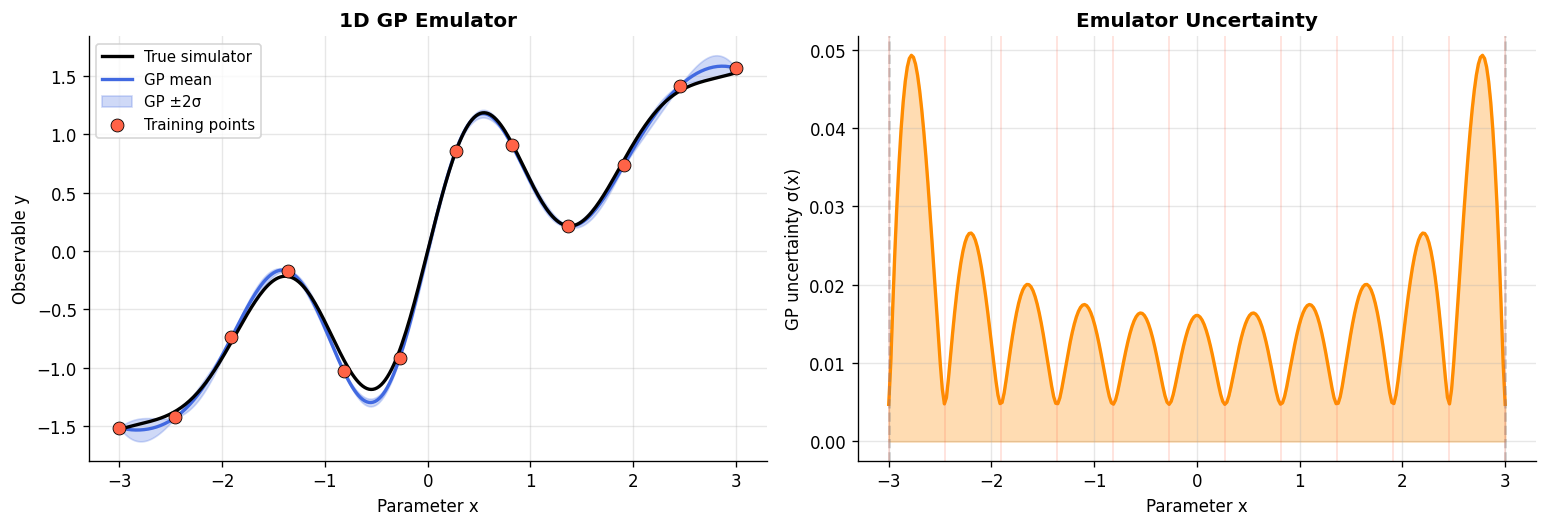


📌 Key insight: uncertainty is LOW near training points, HIGH in between.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.1  Define the true (expensive) simulator
# ─────────────────────────────────────────────────────────────────────────────
def simulator_1d(x):
    """Pretend this is an expensive heavy-ion simulation."""
    return np.sin(3 * x) * np.exp(-0.3 * x**2) + 0.5 * x

x_true = np.linspace(-3, 3, 300)
y_true = simulator_1d(x_true)

# Training points — sparse samples from the simulator
x_train_1d = np.linspace(-3, 3, 12).reshape(-1, 1)
y_train_1d = simulator_1d(x_train_1d.ravel()) + rng.normal(0, 0.05, len(x_train_1d))

# ─────────────────────────────────────────────────────────────────────────────
# 1.2  Train a GP emulator
# ─────────────────────────────────────────────────────────────────────────────
kernel_1d = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10)) \
           + WhiteKernel(noise_level=0.01)

gp_1d = GaussianProcessRegressor(
    kernel=kernel_1d,
    normalize_y=True,
    n_restarts_optimizer=10
)
gp_1d.fit(x_train_1d, y_train_1d)

# Predict on dense grid
x_pred = np.linspace(-3, 3, 300).reshape(-1, 1)
y_pred_1d, y_std_1d = gp_1d.predict(x_pred, return_std=True)

print(f'Optimized kernel: {gp_1d.kernel_}')

# ─────────────────────────────────────────────────────────────────────────────
# 1.3  Plot: true function vs. GP emulator with uncertainty bands
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: GP prediction
ax = axes[0]
ax.plot(x_true, y_true, 'k-', lw=2, label='True simulator', zorder=3)
ax.plot(x_pred, y_pred_1d, 'royalblue', lw=2, label='GP mean', zorder=2)
ax.fill_between(x_pred.ravel(),
                y_pred_1d - 2*y_std_1d,
                y_pred_1d + 2*y_std_1d,
                alpha=0.25, color='royalblue', label='GP ±2σ')
ax.scatter(x_train_1d, y_train_1d, c='tomato', zorder=5, s=60,
           edgecolors='k', lw=0.5, label='Training points', clip_on=False)
ax.set_xlabel('Parameter x'); ax.set_ylabel('Observable y')
ax.set_title('1D GP Emulator', fontweight='bold')
ax.legend(fontsize=9)

# Right: uncertainty (std)
ax = axes[1]
ax.plot(x_pred, y_std_1d, color='darkorange', lw=2)
ax.fill_between(x_pred.ravel(), 0, y_std_1d, alpha=0.3, color='darkorange')
ax.axvline(x_train_1d.ravel()[0], color='gray', ls='--', alpha=0.4)
ax.axvline(x_train_1d.ravel()[-1], color='gray', ls='--', alpha=0.4)
for xt in x_train_1d.ravel():
    ax.axvline(xt, color='tomato', alpha=0.2, lw=1)
ax.set_xlabel('Parameter x'); ax.set_ylabel('GP uncertainty σ(x)')
ax.set_title('Emulator Uncertainty', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📌 Key insight: uncertainty is LOW near training points, HIGH in between.')

### 🧠 Exercise 1.1
> Change the number of training points (e.g. from 12 to 5, then to 20). How does the uncertainty change? What happens at the boundaries?

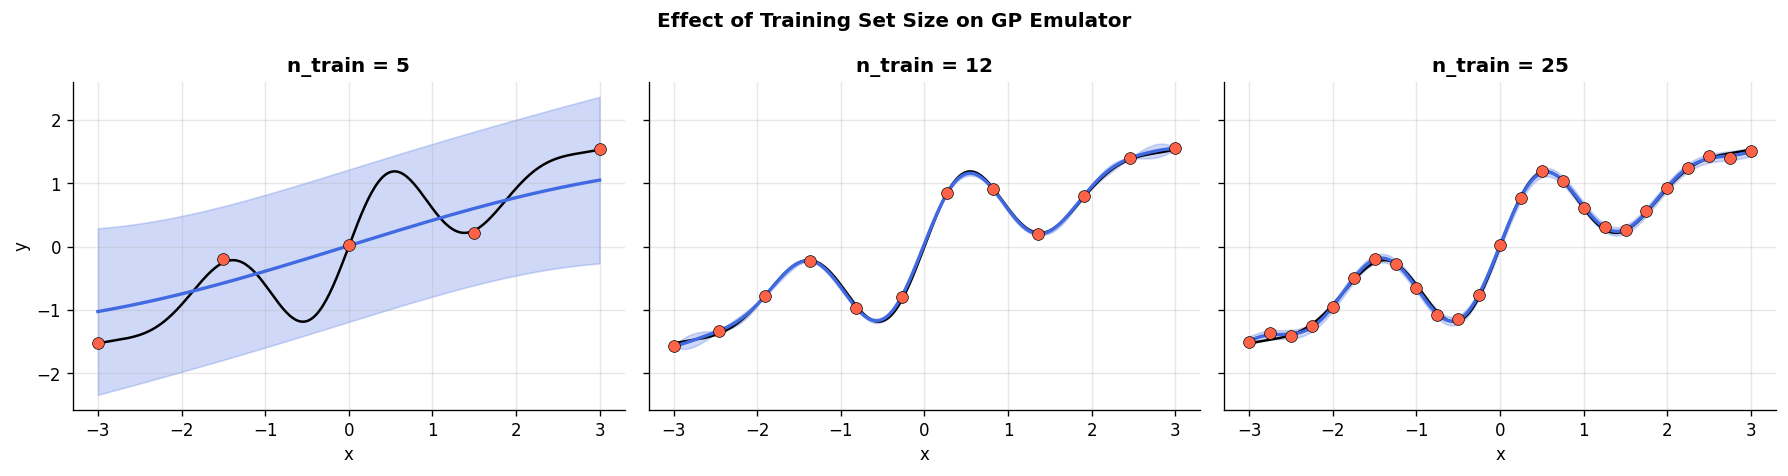

In [3]:
# ── Exercise 1.1 — Try different numbers of training points ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n_pts in zip(axes, [5, 12, 25]):
    x_tr = np.linspace(-3, 3, n_pts).reshape(-1, 1)
    y_tr = simulator_1d(x_tr.ravel()) + rng.normal(0, 0.05, n_pts)

    gp_tmp = GaussianProcessRegressor(
        kernel=C(1.0) * RBF(1.0) + WhiteKernel(0.01),
        normalize_y=True, n_restarts_optimizer=5
    ).fit(x_tr, y_tr)

    y_m, y_s = gp_tmp.predict(x_pred, return_std=True)

    ax.plot(x_true, y_true, 'k-', lw=1.5, label='True')
    ax.plot(x_pred, y_m, 'royalblue', lw=2, label='GP mean')
    ax.fill_between(x_pred.ravel(), y_m - 2*y_s, y_m + 2*y_s,
                    alpha=0.25, color='royalblue')
    ax.scatter(x_tr, y_tr, c='tomato', s=50, zorder=5, edgecolors='k', lw=0.4)
    ax.set_title(f'n_train = {n_pts}', fontweight='bold')
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle('Effect of Training Set Size on GP Emulator', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 🧠 Exercise 1.2 — Kernel comparison
> Try the **Matérn kernel** instead of RBF. The Matérn(ν=3/2) allows rougher functions.

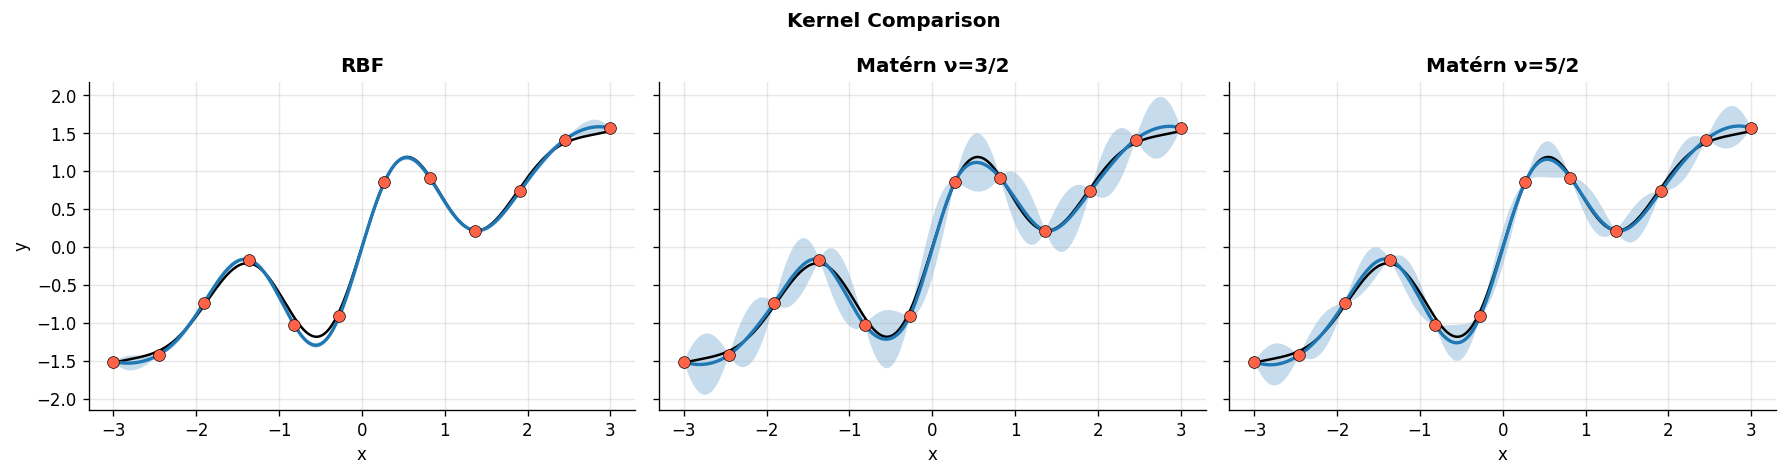

In [4]:
# ── Exercise 1.2 — Compare RBF vs Matérn kernels ─────────────────────────────
kernels = {
    'RBF': C(1.0) * RBF(1.0) + WhiteKernel(0.01),
    'Matérn ν=3/2': C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(0.01),
    'Matérn ν=5/2': C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(0.01),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (kname, kernel) in zip(axes, kernels.items()):
    gp_k = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                    n_restarts_optimizer=5).fit(x_train_1d, y_train_1d)
    y_m, y_s = gp_k.predict(x_pred, return_std=True)

    ax.plot(x_true, y_true, 'k-', lw=1.5, label='True')
    ax.plot(x_pred, y_m, lw=2, label='GP mean')
    ax.fill_between(x_pred.ravel(), y_m-2*y_s, y_m+2*y_s, alpha=0.25)
    ax.scatter(x_train_1d, y_train_1d, c='tomato', s=50, zorder=5,
               edgecolors='k', lw=0.4)
    ax.set_title(kname, fontweight='bold')
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle('Kernel Comparison', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part II — Heavy-Ion Simulation Data

We now simulate a realistic scenario: JETSCAPE-like outputs for **PbPb collisions**.

**Model parameters (inputs X):**
| Parameter | Symbol | Range | Description |
|-----------|--------|-------|--------------|
| Shear viscosity | η/s | [0.01, 0.25] | QGP transport property |
| Bulk viscosity | ζ/s | [0.00, 0.10] | Bulk QGP transport |
| Switching temperature | T_sw | [0.135, 0.165] | Hydro→hadron transition |
| Initial entropy norm | K | [10, 30] | Overall yield normalization |

**Observables (outputs Y):** charged particle multiplicity dN/dη, mean pT, elliptic flow v₂, HBT radii — binned in centrality.

Design matrix X: (200, 4)  (runs × parameters)
Parameter names: ['$\\eta/s$', '$\\zeta/s$', '$T_{\\rm sw}$ [GeV]', '$K$ [norm]']


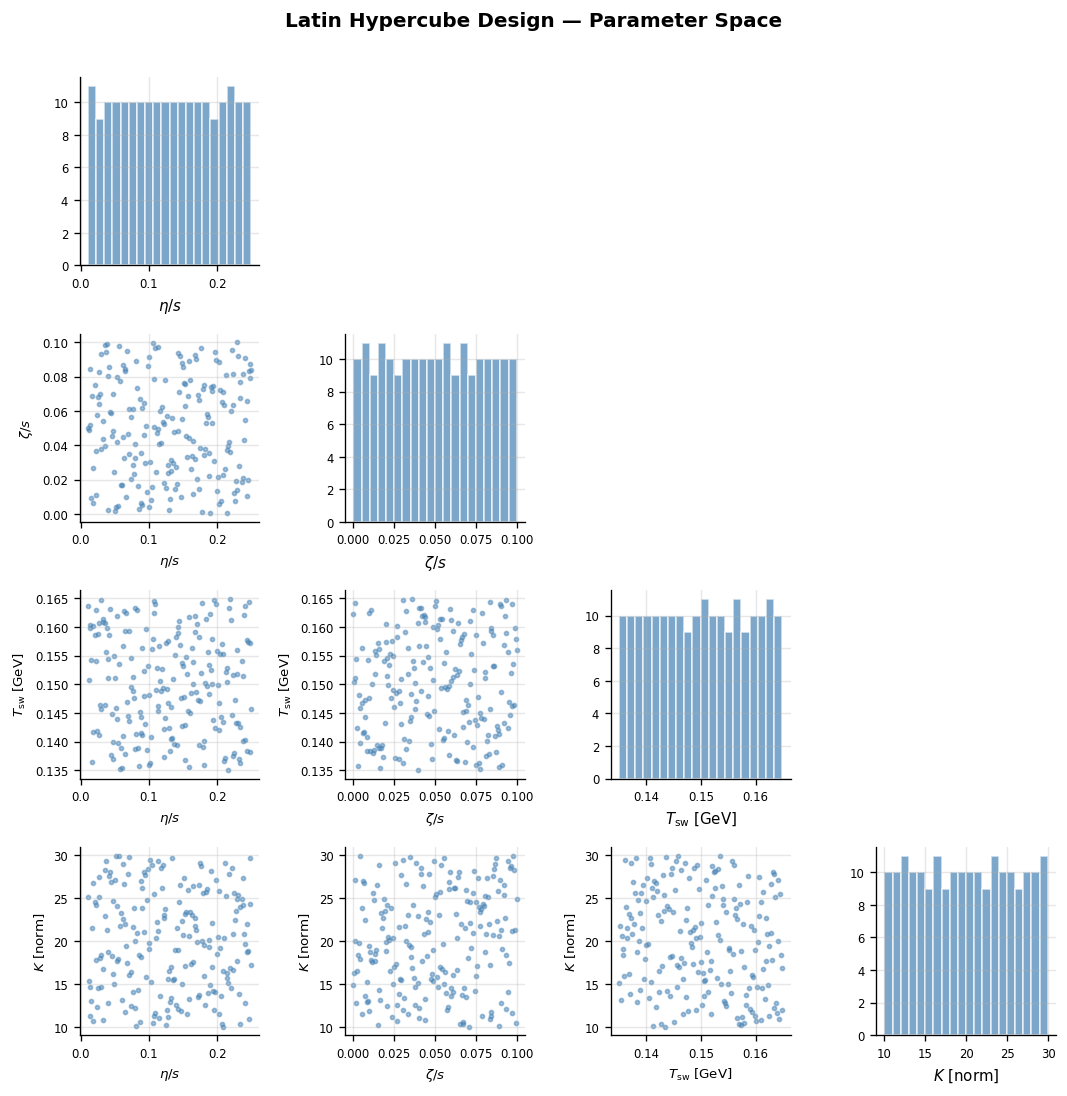

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1  Parameter space (Latin Hypercube Design)
# ─────────────────────────────────────────────────────────────────────────────
def latin_hypercube(n_samples, n_dim, bounds, seed=42):
    """Simple Latin Hypercube Sampling."""
    rng_lh = np.random.default_rng(seed)
    samples = np.zeros((n_samples, n_dim))
    for d in range(n_dim):
        perm = rng_lh.permutation(n_samples)
        samples[:, d] = (perm + rng_lh.uniform(size=n_samples)) / n_samples
    lo, hi = np.array(bounds)[:, 0], np.array(bounds)[:, 1]
    return lo + samples * (hi - lo)

# Parameter bounds: [eta_s, zeta_s, T_sw, K]
param_names = [r'$\eta/s$', r'$\zeta/s$', r'$T_{\rm sw}$ [GeV]', r'$K$ [norm]']
param_bounds = [[0.01, 0.25], [0.00, 0.10], [0.135, 0.165], [10.0, 30.0]]

N_DESIGN = 200   # number of design points (= model runs)
X = latin_hypercube(N_DESIGN, 4, param_bounds, seed=0)

# Centrality bins
centrality_bins = ['0-5%', '5-10%', '10-20%', '20-30%', '30-40%', '40-50%']
n_cent = len(centrality_bins)

print(f'Design matrix X: {X.shape}  (runs × parameters)')
print(f'Parameter names: {param_names}')

# Visualise the design
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            ax.hist(X[:, i], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
            ax.set_xlabel(param_names[i], fontsize=9)
        elif i > j:
            ax.scatter(X[:, j], X[:, i], s=6, alpha=0.5, color='steelblue')
            ax.set_xlabel(param_names[j], fontsize=8)
            ax.set_ylabel(param_names[i], fontsize=8)
        else:
            ax.axis('off')
        ax.tick_params(labelsize=7)

plt.suptitle('Latin Hypercube Design — Parameter Space', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2  Synthetic "simulator" — realistic heavy-ion observables
#      (mimics JETSCAPE physics trends with added noise)
# ─────────────────────────────────────────────────────────────────────────────
def simulate_heavy_ion(X_params, noise_level=0.02, seed=42):
    """
    Synthetic heavy-ion simulator producing:
      - dN/deta  : charged particle multiplicity (6 centrality bins)
      - mean_pT  : mean transverse momentum      (6 centrality bins)
      - v2       : elliptic flow coefficient     (6 centrality bins)

    Physics trends (simplified):
      - dN/deta  increases with K, weakly depends on eta_s
      - mean_pT  increases with eta_s (radial flow), decreases toward periphery
      - v2       increases with centrality, suppressed by eta_s
    """
    rng_sim = np.random.default_rng(seed)
    N, _ = X_params.shape
    eta_s, zeta_s, T_sw, K = X_params.T

    # Centrality weights (0-5% most central → smallest geometric size)
    cent_w = np.array([0.95, 0.85, 0.72, 0.58, 0.44, 0.30])   # <Npart>/Npart_max
    ecc    = np.array([0.10, 0.16, 0.25, 0.35, 0.44, 0.51])   # eccentricity

    observables = []
    for c, (cw, eps) in enumerate(zip(cent_w, ecc)):
        # dN/deta: driven by entropy K, suppressed by T_sw, ~cw scaling
        dNdeta = (K * 50 * cw
                  * (1 - 0.5 * (T_sw - 0.15) / 0.015)
                  * (1 - 0.3 * eta_s)
                  * np.exp(-5 * zeta_s))

        # mean pT: radial flow → increases with eta_s (more pressure gradient)
        mean_pT = (0.55 + 0.8 * cw
                   + 1.2 * eta_s
                   - 0.5 * (T_sw - 0.15) / 0.015
                   - 2.0 * zeta_s)

        # v2: eccentricity × response, suppressed by viscosity
        v2 = eps * (0.18 - 1.5 * eta_s - 0.8 * zeta_s) * (1 + 0.3 * cw)
        v2 = np.clip(v2, 0, None)

        observables.extend([dNdeta, mean_pT, v2])

    Y = np.column_stack(observables)

    # Add correlated noise
    Y *= (1 + rng_sim.normal(0, noise_level, Y.shape))
    return Y

Y = simulate_heavy_ion(X, noise_level=0.025)
print(f'Observables matrix Y: {Y.shape}  (runs × observables)')

# Build column names
obs_types  = ['dN/dη', '⟨pT⟩', 'v₂']
obs_labels = [f'{obs} ({cent})' for cent in centrality_bins for obs in obs_types]
print(f'\nObservables ({len(obs_labels)} total):')
for i, lbl in enumerate(obs_labels):
    print(f'  [{i:02d}] {lbl}')

Observables matrix Y: (200, 18)  (runs × observables)

Observables (18 total):
  [00] dN/dη (0-5%)
  [01] ⟨pT⟩ (0-5%)
  [02] v₂ (0-5%)
  [03] dN/dη (5-10%)
  [04] ⟨pT⟩ (5-10%)
  [05] v₂ (5-10%)
  [06] dN/dη (10-20%)
  [07] ⟨pT⟩ (10-20%)
  [08] v₂ (10-20%)
  [09] dN/dη (20-30%)
  [10] ⟨pT⟩ (20-30%)
  [11] v₂ (20-30%)
  [12] dN/dη (30-40%)
  [13] ⟨pT⟩ (30-40%)
  [14] v₂ (30-40%)
  [15] dN/dη (40-50%)
  [16] ⟨pT⟩ (40-50%)
  [17] v₂ (40-50%)


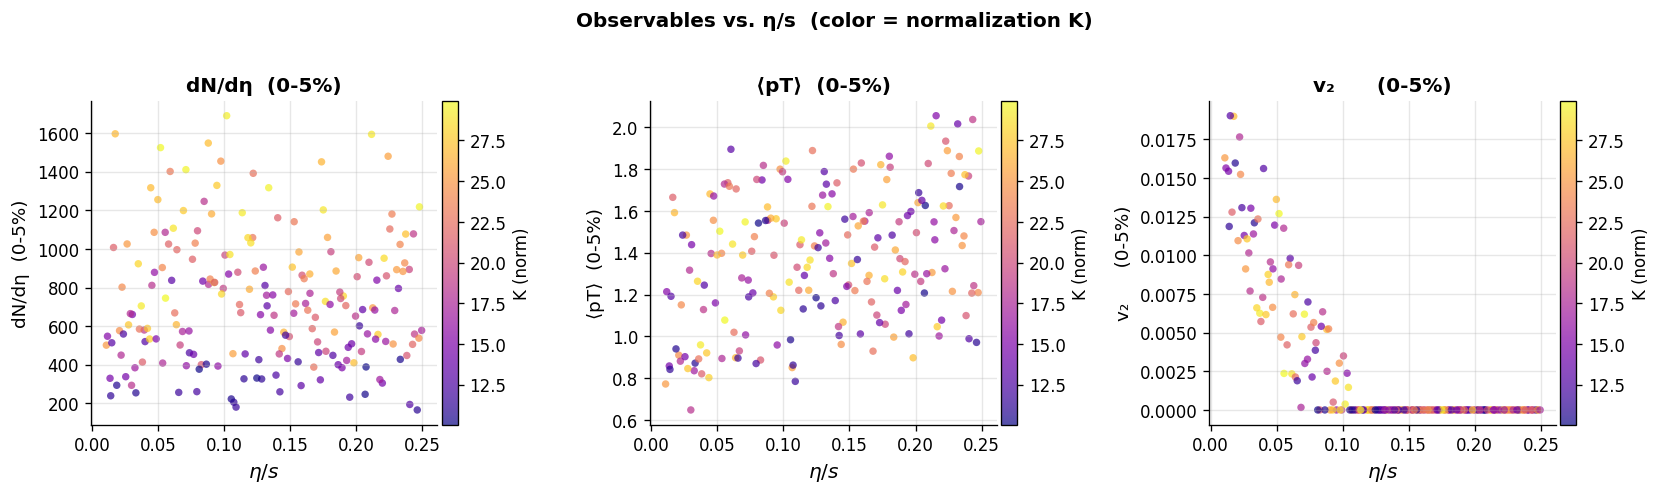

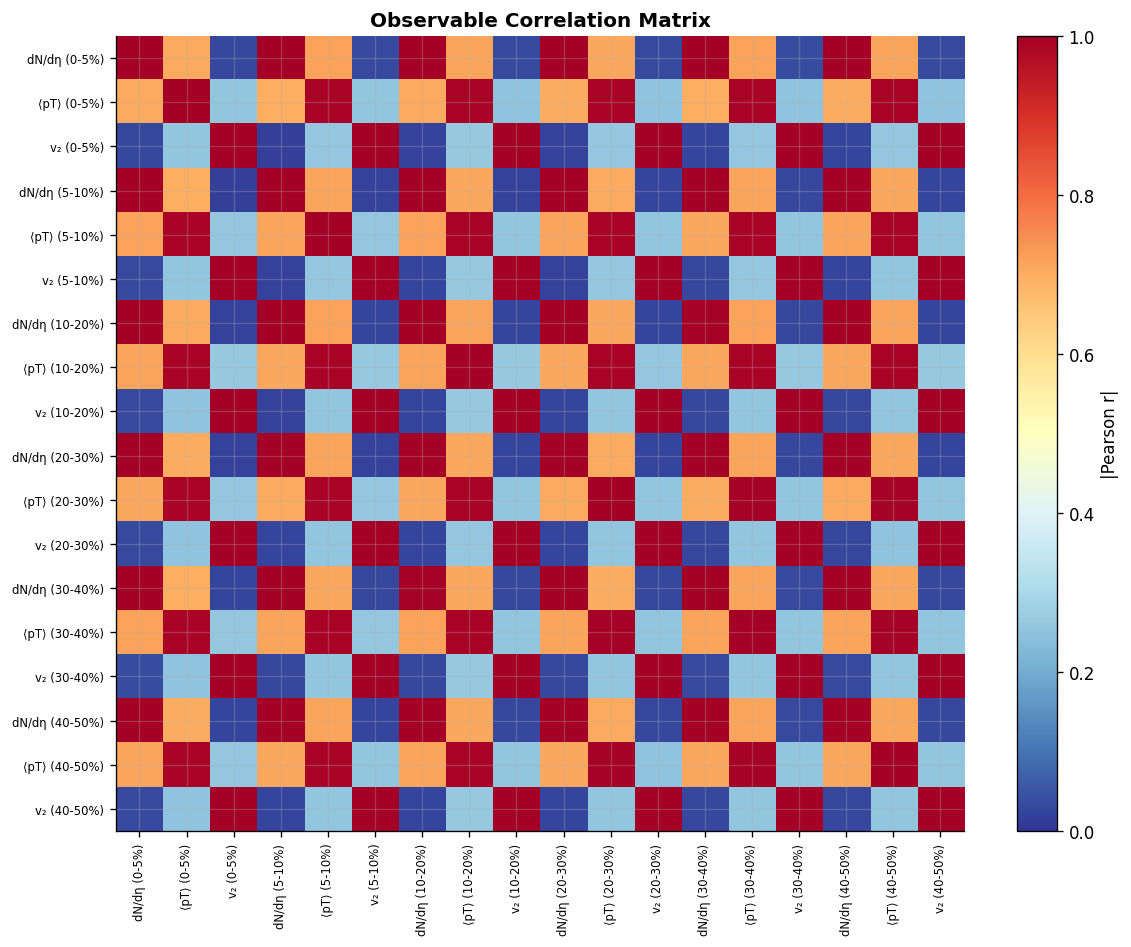

📌 High correlations → PCA will efficiently compress this information!


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.3  Explore the observables
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

eta_s = X[:, 0]
K     = X[:, 3]

for ax, (obs_idx, obs_name, color) in zip(axes, [
    (0,  'dN/dη  (0-5%)',   'steelblue'),
    (1,  '⟨pT⟩  (0-5%)',    'darkorange'),
    (2,  'v₂      (0-5%)',   'seagreen'),
]):
    sc = ax.scatter(eta_s, Y[:, obs_idx], c=K, cmap='plasma',
                   s=20, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='K (norm)', pad=0.01)
    ax.set_xlabel(r'$\eta/s$', fontsize=12)
    ax.set_ylabel(obs_name, fontsize=11)
    ax.set_title(obs_name, fontweight='bold')

plt.suptitle('Observables vs. η/s  (color = normalization K)', y=1.02,
             fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = np.corrcoef(Y.T)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.abs(corr), aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|Pearson r|')
ax.set_xticks(range(len(obs_labels))); ax.set_xticklabels(obs_labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(obs_labels))); ax.set_yticklabels(obs_labels, fontsize=7)
ax.set_title('Observable Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 High correlations → PCA will efficiently compress this information!')

---
## Part III — Preprocessing: Standardization & PCA

### 3.1 Why preprocess?

- **Standardization:** Observables have very different scales (dN/dη ≈ 1000, v₂ ≈ 0.05). The GP kernel treats all dimensions equally, so we must put everything on the same scale.
- **PCA:** The 18 observables are highly correlated. PCA finds the **principal components** (orthogonal directions of maximum variance), letting us compress 18 observables into a few independent PC scores — each emulated by a **separate, simpler GP**.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1  Train / Validation split
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=0
)
print(f'Train: {X_train.shape[0]} samples  |  Validation: {X_val.shape[0]} samples')

Train: 160 samples  |  Validation: 40 samples


Before standardization:
  Y_train mean range: [0.0, 718.4]
  Y_train std  range: [0.005, 335.8]

After standardization:
  Y_train_std mean range: [-0.0000, 0.0000]  (≈ 0)
  Y_train_std std  range: [1.0000, 1.0000]   (≈ 1)


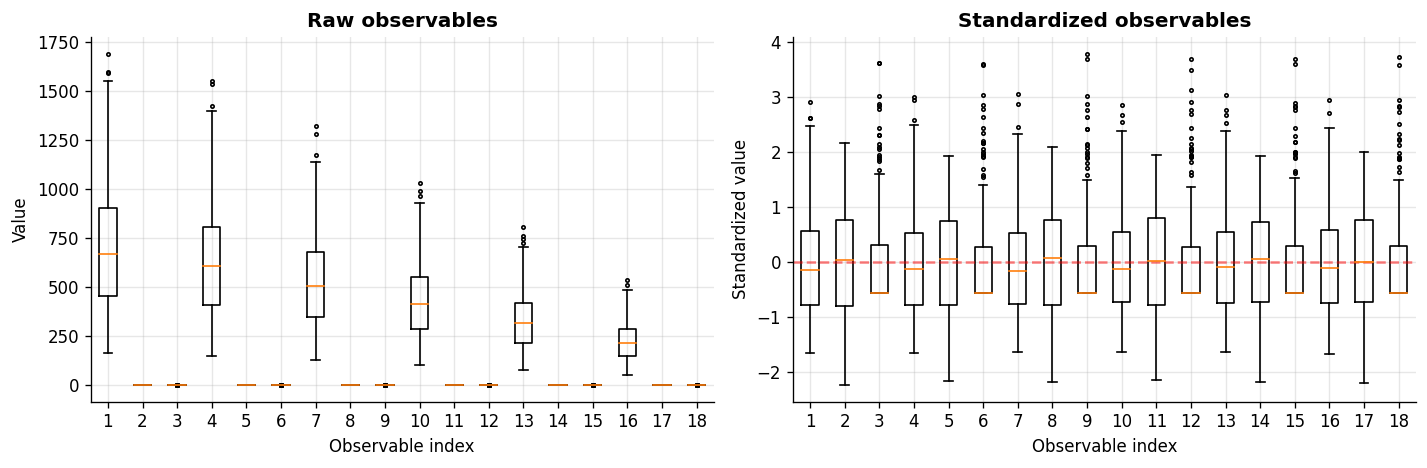

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.2  Standardization
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
Y_train_std = scaler.fit_transform(Y_train)   # fit on train only!
Y_val_std   = scaler.transform(Y_val)          # apply same transform to val

print('Before standardization:')
print(f'  Y_train mean range: [{Y_train.mean(axis=0).min():.1f}, {Y_train.mean(axis=0).max():.1f}]')
print(f'  Y_train std  range: [{Y_train.std(axis=0).min():.3f}, {Y_train.std(axis=0).max():.1f}]')

print('\nAfter standardization:')
print(f'  Y_train_std mean range: [{Y_train_std.mean(axis=0).min():.4f}, {Y_train_std.mean(axis=0).max():.4f}]  (≈ 0)')
print(f'  Y_train_std std  range: [{Y_train_std.std(axis=0).min():.4f}, {Y_train_std.std(axis=0).max():.4f}]   (≈ 1)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([Y_train[:, i] for i in range(Y_train.shape[1])],
                flierprops={'markersize': 2})
axes[0].set_title('Raw observables', fontweight='bold')
axes[0].set_xlabel('Observable index'); axes[0].set_ylabel('Value')

axes[1].boxplot([Y_train_std[:, i] for i in range(Y_train_std.shape[1])],
                flierprops={'markersize': 2})
axes[1].set_title('Standardized observables', fontweight='bold')
axes[1].set_xlabel('Observable index'); axes[1].set_ylabel('Standardized value')
axes[1].axhline(0, ls='--', color='red', alpha=0.5)

plt.tight_layout()
plt.show()

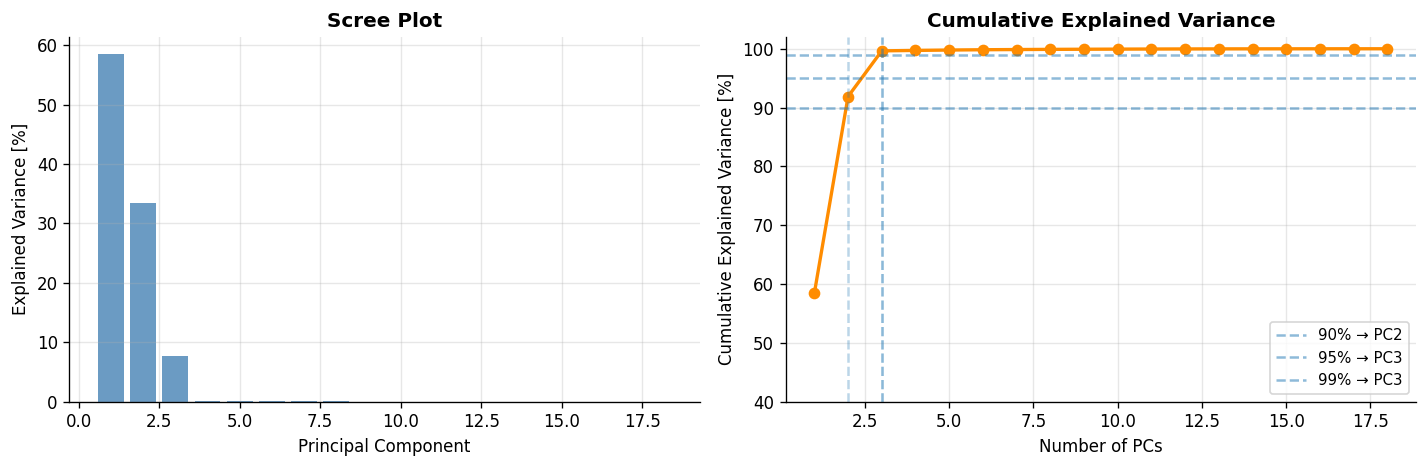


📌 3 PCs explain 99.64% of variance
   Original dimensionality: 18
   Compressed to:           3  (17% of original)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.3  Principal Component Analysis
# ─────────────────────────────────────────────────────────────────────────────
pca = PCA()   # keep all components first
Z_train_all = pca.fit_transform(Y_train_std)
Z_val_all   = pca.transform(Y_val_std)

# Explained variance
ev_ratio = pca.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, len(ev_ratio)+1), ev_ratio * 100, color='steelblue', alpha=0.8)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance [%]')
ax.set_title('Scree Plot', fontweight='bold')

ax = axes[1]
ax.plot(range(1, len(ev_cumsum)+1), ev_cumsum * 100, 'o-', color='darkorange', lw=2)
for threshold in [0.90, 0.95, 0.99]:
    n_pc = np.searchsorted(ev_cumsum, threshold) + 1
    ax.axhline(threshold * 100, ls='--', alpha=0.5, label=f'{threshold*100:.0f}% → PC{n_pc}')
    ax.axvline(n_pc, ls='--', alpha=0.3)
ax.set_xlabel('Number of PCs'); ax.set_ylabel('Cumulative Explained Variance [%]')
ax.set_title('Cumulative Explained Variance', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(40, 102)

plt.tight_layout()
plt.show()

# How many PCs to keep?
N_PC = np.searchsorted(ev_cumsum, 0.99) + 1
print(f'\n📌 {N_PC} PCs explain {ev_cumsum[N_PC-1]*100:.2f}% of variance')
print(f'   Original dimensionality: {Y_train.shape[1]}')
print(f'   Compressed to:           {N_PC}  ({100*N_PC/Y_train.shape[1]:.0f}% of original)')

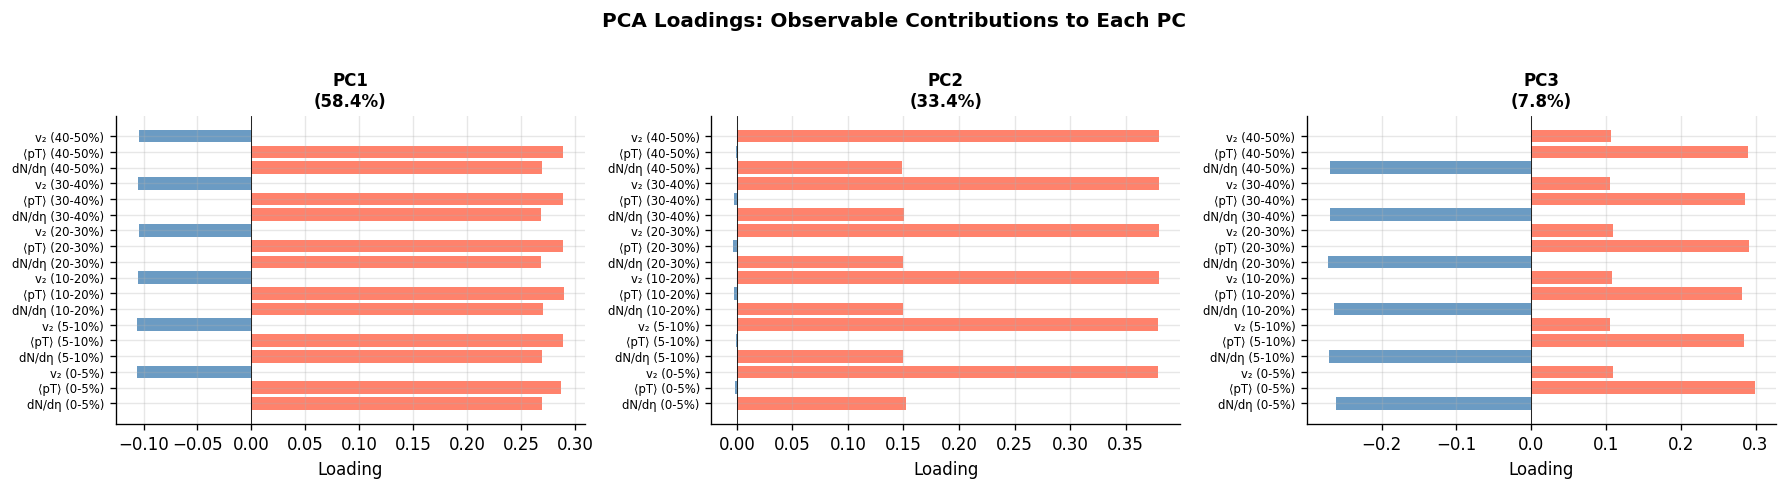


PC scores shape: Z_train=(160, 3), Z_val=(40, 3)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.4  PCA components: what do they represent?
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, min(N_PC, 5), figsize=(15, 4), sharey=False)

for pc_idx in range(min(N_PC, 5)):
    ax = axes[pc_idx] if min(N_PC,5) > 1 else axes
    loadings = pca.components_[pc_idx]
    colors_load = ['tomato' if v > 0 else 'steelblue' for v in loadings]
    ax.barh(range(len(loadings)), loadings, color=colors_load, alpha=0.8)
    ax.set_yticks(range(len(obs_labels)))
    ax.set_yticklabels(obs_labels, fontsize=7)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'PC{pc_idx+1}\n({ev_ratio[pc_idx]*100:.1f}%)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Loading')

plt.suptitle('PCA Loadings: Observable Contributions to Each PC',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Keep only N_PC components
Z_train = Z_train_all[:, :N_PC]
Z_val   = Z_val_all[:, :N_PC]
print(f'\nPC scores shape: Z_train={Z_train.shape}, Z_val={Z_val.shape}')

### Helper functions for transforming between observable space and PC space

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.5  Transform helpers
# ─────────────────────────────────────────────────────────────────────────────
def transform_to_PC_space(Y_obs, scaler, pca, n_pc):
    """Observable space → PC space (n_pc components).

    Parameters
    ----------
    Y_obs   : array (n_samples, n_obs)  — raw observable values
    scaler  : fitted StandardScaler
    pca     : fitted PCA
    n_pc    : number of PCs to return

    Returns
    -------
    Z : array (n_samples, n_pc)  — PC scores
    """
    Y_std = scaler.transform(Y_obs)
    Z     = pca.transform(Y_std)
    return Z[:, :n_pc]


def inverse_transform_from_PC_space(Z_pc, scaler, pca, n_pc):
    """PC space → observable space.

    Parameters
    ----------
    Z_pc   : array (n_samples, n_pc)  — PC scores (truncated)
    scaler : fitted StandardScaler
    pca    : fitted PCA
    n_pc   : number of PCs used

    Returns
    -------
    Y_pred : array (n_samples, n_obs)  — reconstructed observables
    """
    # Pad with zeros for unused PCs
    n_components_total = pca.components_.shape[0]
    Z_padded = np.zeros((Z_pc.shape[0], n_components_total))
    Z_padded[:, :n_pc] = Z_pc

    Y_std  = pca.inverse_transform(Z_padded)
    Y_pred = scaler.inverse_transform(Y_std)
    return Y_pred


# Quick sanity check: round-trip transform
Z_check  = transform_to_PC_space(Y_train, scaler, pca, N_PC)
Y_check  = inverse_transform_from_PC_space(Z_check, scaler, pca, N_PC)
max_err  = np.abs(Y_train - Y_check).max()
rel_err  = (np.abs(Y_train - Y_check) / (np.abs(Y_train) + 1e-8)).mean()

print('Round-trip test (Y → PC → Y):')
print(f'  Max absolute error : {max_err:.4f}')
print(f'  Mean relative error: {rel_err*100:.3f}%  (truncation from using {N_PC}/{Y_train.shape[1]} PCs)')

Round-trip test (Y → PC → Y):
  Max absolute error : 58.7243
  Mean relative error: 66582.172%  (truncation from using 3/18 PCs)


---
## Part IV — Building GP Emulators

We train **one GP per PC**, mapping: **parameter vector X → PC score Zᵢ**

The kernel choice:
$$k(x, x') = \sigma_f^2 \cdot \text{RBF}(x, x'; \ell) + \sigma_n^2 \delta(x, x')$$

- $\sigma_f^2$ : signal variance (amplitude)
- $\ell$ : length scale (how quickly the function varies with each parameter)
- $\sigma_n^2$ : noise variance (WhiteKernel)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1  Train GP emulators — one per PC
# ─────────────────────────────────────────────────────────────────────────────
def build_emulators(X_train, Z_train, n_pc, n_restarts=5):
    """
    Train one GP emulator per principal component.

    Kernel: ConstantKernel × RBF (ARD) + WhiteKernel
    ARD = Automatic Relevance Determination: separate length scale per input parameter.
    """
    n_params = X_train.shape[1]
    gps = []

    for i in range(n_pc):
        kernel = (
            C(1.0, (1e-3, 1e3))
            * RBF(length_scale=np.ones(n_params),
                  length_scale_bounds=[(1e-2, 1e2)] * n_params)
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e0))
        )
        gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=n_restarts,
        )
        gp.fit(X_train, Z_train[:, i])
        gps.append(gp)
        print(f'  PC{i+1:02d}: log-marginal-likelihood = {gp.log_marginal_likelihood_value_:.2f}',
              f' | noise σ = {np.sqrt(gp.kernel_.k2.noise_level):.4f}')

    return gps

print(f'Training {N_PC} GP emulators (this may take ~30 seconds)...')
gps = build_emulators(X_train, Z_train, N_PC, n_restarts=5)
print(f'\n✅ {N_PC} emulators trained.')

Training 3 GP emulators (this may take ~30 seconds)...
  PC01: log-marginal-likelihood = 229.62  | noise σ = 0.0358
  PC02: log-marginal-likelihood = 169.06  | noise σ = 0.0245
  PC03: log-marginal-likelihood = 84.06  | noise σ = 0.0748

✅ 3 emulators trained.


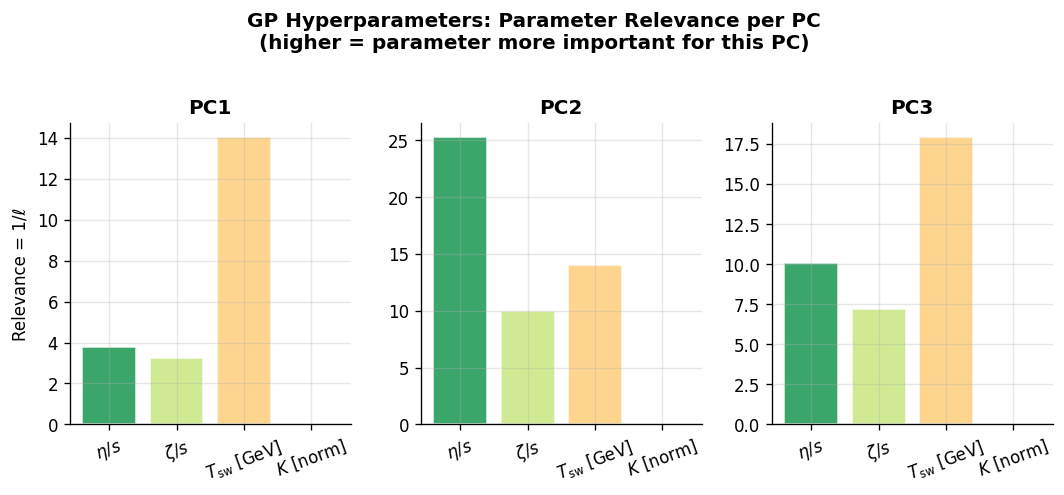

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2  Inspect hyperparameters: which parameters matter most?
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_PC, figsize=(3*N_PC, 4), sharey=False)
if N_PC == 1:
    axes = [axes]

for pc_idx, (gp, ax) in enumerate(zip(gps, axes)):
    # Length scales from ARD RBF kernel
    ls = gp.kernel_.k1.k2.length_scale
    colors_ls = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ls)))
    bars = ax.bar(param_names, 1.0/ls, color=colors_ls, edgecolor='white', alpha=0.85)
    ax.set_title(f'PC{pc_idx+1}', fontweight='bold')
    ax.set_ylabel('Relevance = 1/ℓ' if pc_idx == 0 else '')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('GP Hyperparameters: Parameter Relevance per PC\n'
             '(higher = parameter more important for this PC)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.3  Predict + reconstruct observables
# ─────────────────────────────────────────────────────────────────────────────
def emulate(X_new, gps, scaler, pca, n_pc, return_std=False):
    """
    Full pipeline: X → emulated PC scores → reconstructed observables.

    Parameters
    ----------
    X_new      : array (n_samples, n_params)
    gps        : list of trained GPs (one per PC)
    scaler     : fitted StandardScaler
    pca        : fitted PCA
    n_pc       : number of PCs used
    return_std : also return uncertainty on observables

    Returns
    -------
    Y_pred   : array (n_samples, n_obs)
    Y_std    : array (n_samples, n_obs)  [only if return_std=True]
    """
    Z_means = np.zeros((X_new.shape[0], n_pc))
    Z_stds  = np.zeros((X_new.shape[0], n_pc))

    for i, gp in enumerate(gps):
        mu, sigma = gp.predict(X_new, return_std=True)
        Z_means[:, i] = mu
        Z_stds[:, i]  = sigma

    Y_pred = inverse_transform_from_PC_space(Z_means, scaler, pca, n_pc)

    if return_std:
        # Propagate PC uncertainty back to observable space
        # σ_Y = |W| × σ_Z  where W is the (truncated) PCA loading matrix
        W = pca.components_[:n_pc, :]            # (n_pc, n_obs)
        # Scale by observable std (from scaler)
        obs_scale = scaler.scale_                # (n_obs,)
        Y_std = np.sqrt((Z_stds**2) @ (W**2)) * obs_scale
        return Y_pred, Y_std

    return Y_pred


# Predict on validation set
Y_pred, Y_pred_std = emulate(X_val, gps, scaler, pca, N_PC, return_std=True)
print(f'Y_pred shape      : {Y_pred.shape}')
print(f'Y_pred_std shape  : {Y_pred_std.shape}')
print(f'Mean emulator σ   : {Y_pred_std.mean():.4f} (in original units)')

Y_pred shape      : (40, 18)
Y_pred_std shape  : (40, 18)
Mean emulator σ   : 3.6743 (in original units)


---
## Part V — Emulator Validation

We validate the emulator by comparing its predictions on the **held-out validation set** against the actual simulator outputs.

**Metrics:**
- $R^2$ coefficient of determination (1 = perfect)
- Normalized residuals $\varepsilon_i = (y_{\rm pred} - y_{\rm true}) / \sigma_{\rm pred}$  
  → Should follow $\mathcal{N}(0, 1)$ if the emulator is well-calibrated

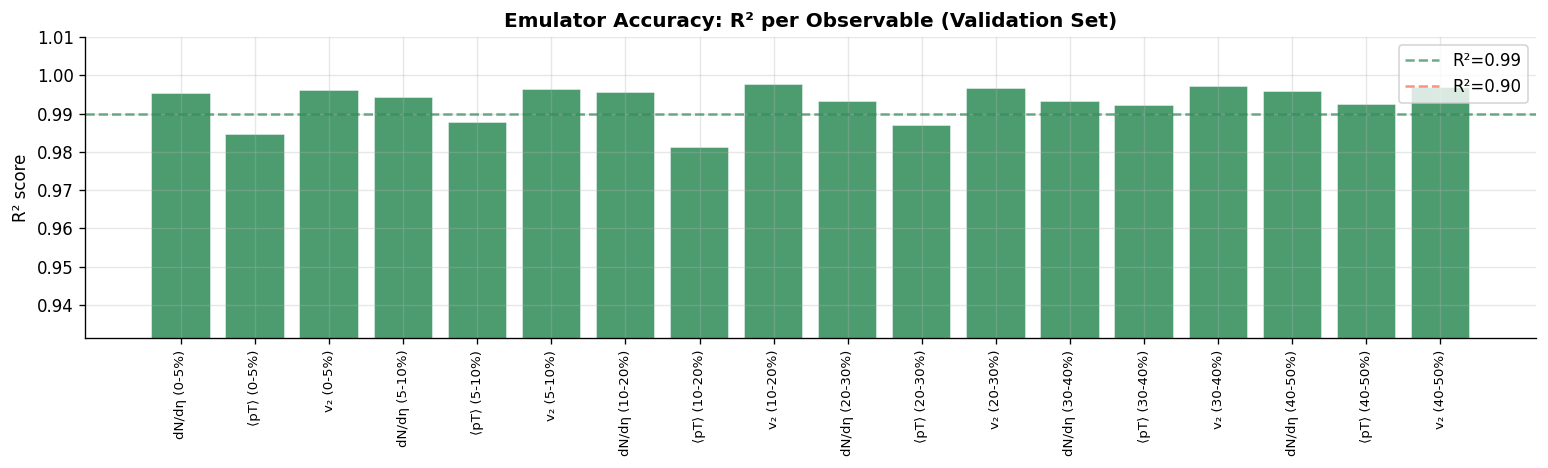

Median R² = 0.9949
Min    R² = 0.9814  (observable: ⟨pT⟩ (10-20%))


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1  Overall R² per observable
# ─────────────────────────────────────────────────────────────────────────────
r2_scores = [r2_score(Y_val[:, i], Y_pred[:, i]) for i in range(Y_val.shape[1])]

fig, ax = plt.subplots(figsize=(13, 4))
colors_r2 = ['tomato' if r < 0.90 else 'goldenrod' if r < 0.97 else 'seagreen'
             for r in r2_scores]
bars = ax.bar(range(len(r2_scores)), r2_scores, color=colors_r2, alpha=0.85,
              edgecolor='white')
ax.axhline(0.99, ls='--', color='seagreen', alpha=0.7, label='R²=0.99')
ax.axhline(0.90, ls='--', color='tomato',   alpha=0.7, label='R²=0.90')
ax.set_xticks(range(len(obs_labels)))
ax.set_xticklabels(obs_labels, rotation=90, fontsize=8)
ax.set_ylabel('R² score')
ax.set_ylim(max(0, min(r2_scores)-0.05), 1.01)
ax.set_title('Emulator Accuracy: R² per Observable (Validation Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median R² = {np.median(r2_scores):.4f}')
print(f'Min    R² = {min(r2_scores):.4f}  (observable: {obs_labels[np.argmin(r2_scores)]})')

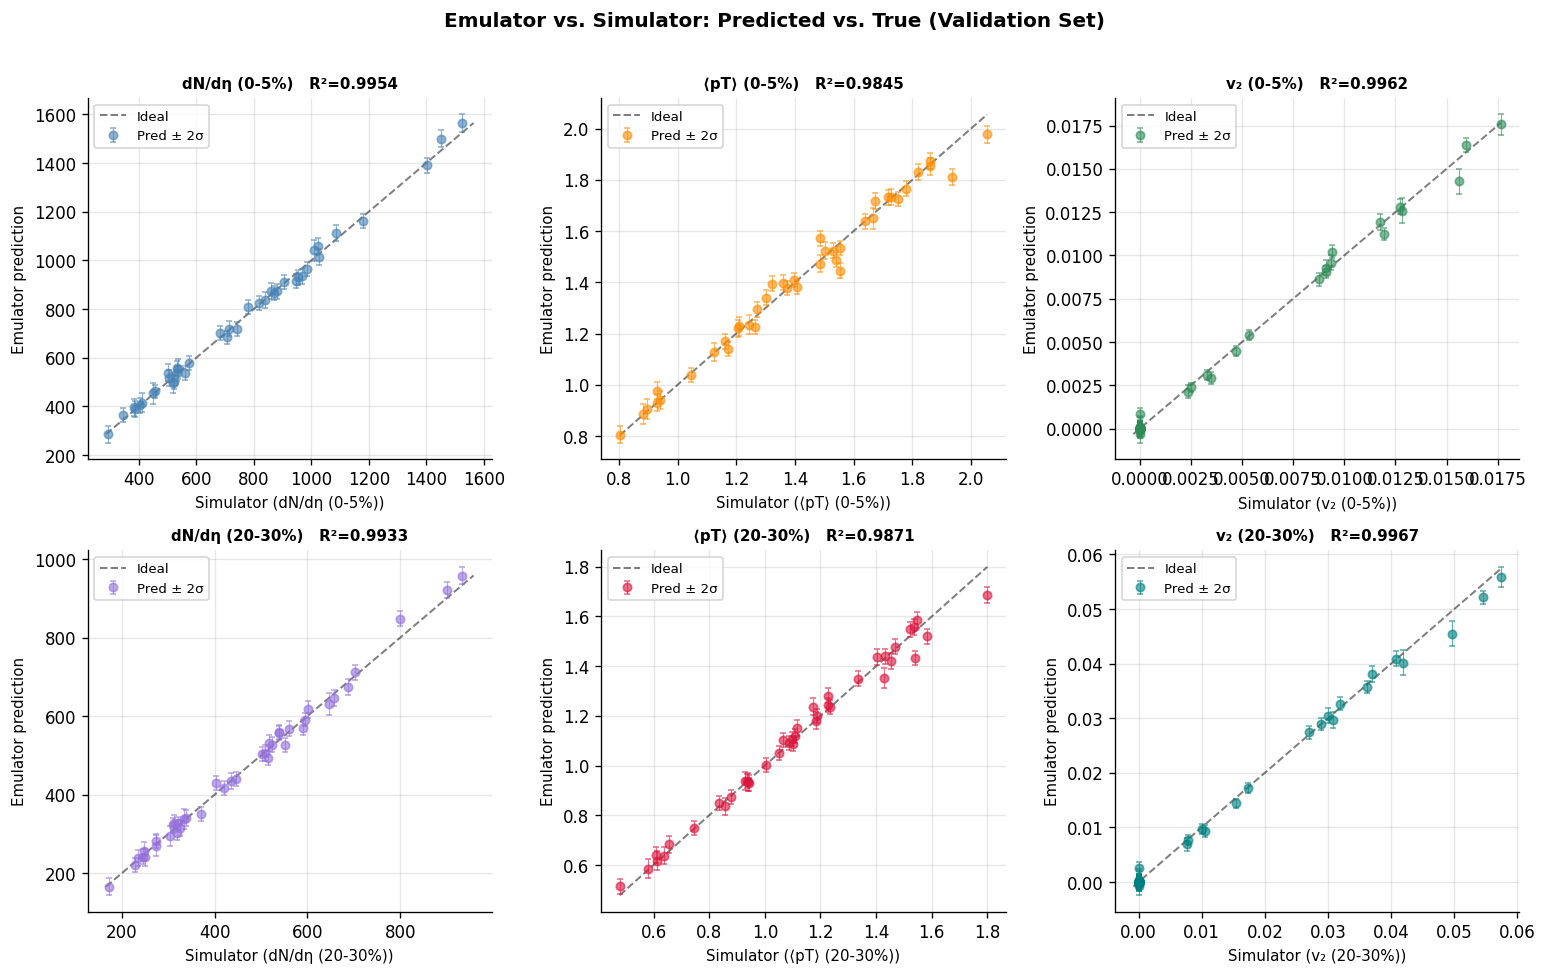

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2  Predicted vs. true scatter plots for key observables
# ─────────────────────────────────────────────────────────────────────────────
key_obs = [
    (0,  'dN/dη (0-5%)',  'steelblue'),
    (1,  '⟨pT⟩ (0-5%)',   'darkorange'),
    (2,  'v₂ (0-5%)',      'seagreen'),
    (9,  'dN/dη (20-30%)', 'mediumpurple'),
    (10, '⟨pT⟩ (20-30%)',  'crimson'),
    (11, 'v₂ (20-30%)',    'teal'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, (obs_idx, obs_name, color) in zip(axes, key_obs):
    y_t = Y_val[:, obs_idx]
    y_p = Y_pred[:, obs_idx]
    y_s = Y_pred_std[:, obs_idx]
    r2  = r2_score(y_t, y_p)

    # Diagonal reference
    lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Ideal')

    # Error bars from GP uncertainty
    ax.errorbar(y_t, y_p, yerr=2*y_s, fmt='o', color=color,
                alpha=0.6, markersize=5, elinewidth=0.7, capsize=2,
                label='Pred ± 2σ')

    ax.set_xlabel(f'Simulator ({obs_name})', fontsize=9)
    ax.set_ylabel('Emulator prediction', fontsize=9)
    ax.set_title(f'{obs_name}   R²={r2:.4f}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Emulator vs. Simulator: Predicted vs. True (Validation Set)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

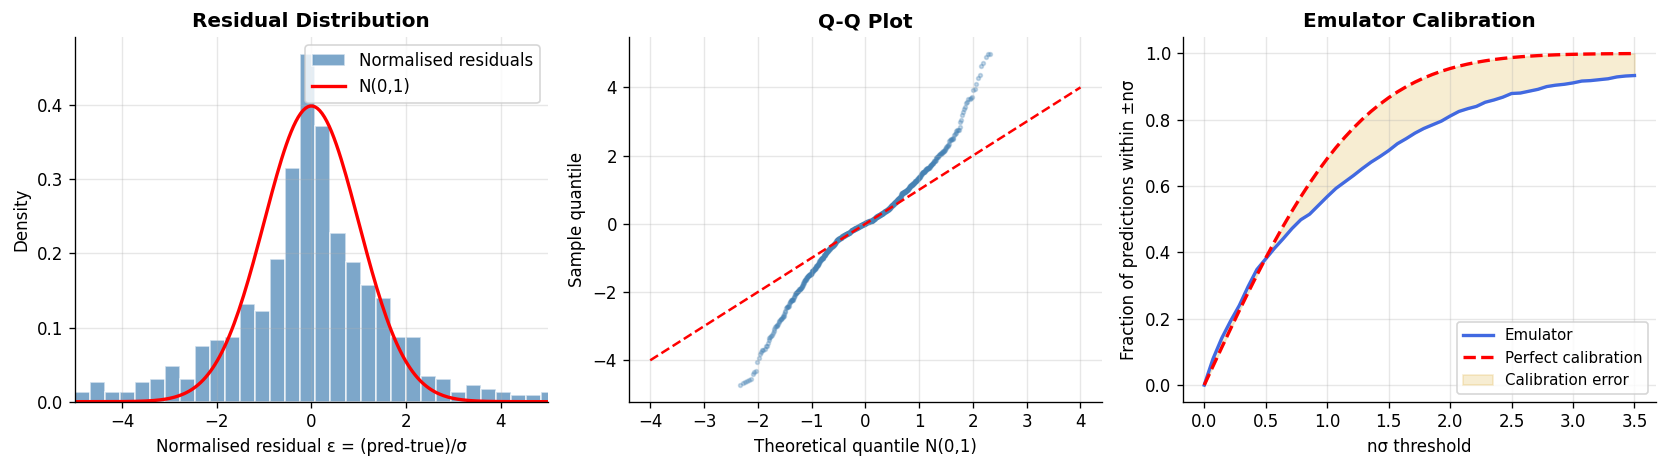


Calibration check:
  |ε| < 1σ:  emulator=56.8%   expected=68.3%
  |ε| < 2σ:  emulator=81.1%   expected=95.4%
  |ε| < 3σ:  emulator=91.1%   expected=99.7%


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.3  Residuals analysis: are errors Gaussian?
# ─────────────────────────────────────────────────────────────────────────────
residuals_raw = Y_val - Y_pred

# Normalised residuals: ε = (pred - true) / σ_emulator
eps_norm = residuals_raw / (Y_pred_std + 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: residual distribution (all observables stacked)
ax = axes[0]
all_res = eps_norm.ravel()
ax.hist(all_res, bins=50, density=True, color='steelblue', alpha=0.7,
        edgecolor='white', label='Normalised residuals')
x_g = np.linspace(-5, 5, 200)
ax.plot(x_g, np.exp(-0.5*x_g**2)/np.sqrt(2*np.pi), 'r-', lw=2, label='N(0,1)')
ax.set_xlabel('Normalised residual ε = (pred-true)/σ')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution', fontweight='bold')
ax.legend()
ax.set_xlim(-5, 5)

# Middle: QQ plot
ax = axes[1]
from scipy.stats import norm, probplot
sorted_res = np.sort(all_res[np.isfinite(all_res)])
n = len(sorted_res)
theoretical_q = norm.ppf(np.linspace(0.01, 0.99, n))
practical_q   = np.quantile(sorted_res, np.linspace(0.01, 0.99, n))
ax.scatter(theoretical_q, practical_q, s=5, alpha=0.3, color='steelblue')
ax.plot([-4, 4], [-4, 4], 'r--', lw=1.5)
ax.set_xlabel('Theoretical quantile N(0,1)')
ax.set_ylabel('Sample quantile')
ax.set_title('Q-Q Plot', fontweight='bold')

# Right: calibration — fraction within ±nσ
ax = axes[2]
sigma_levels = np.linspace(0, 3.5, 50)
fracs = [np.mean(np.abs(eps_norm.ravel()) < s) for s in sigma_levels]
expected = [2*norm.cdf(s) - 1 for s in sigma_levels]
ax.plot(sigma_levels, fracs, 'royalblue', lw=2, label='Emulator')
ax.plot(sigma_levels, expected, 'r--', lw=2, label='Perfect calibration')
ax.fill_between(sigma_levels, expected, fracs,
                alpha=0.2, color='goldenrod', label='Calibration error')
ax.set_xlabel('nσ threshold')
ax.set_ylabel('Fraction of predictions within ±nσ')
ax.set_title('Emulator Calibration', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nCalibration check:')
for s in [1, 2, 3]:
    frac = np.mean(np.abs(eps_norm.ravel()) < s)
    exp  = 2*norm.cdf(s) - 1
    print(f'  |ε| < {s}σ:  emulator={frac*100:.1f}%   expected={exp*100:.1f}%')

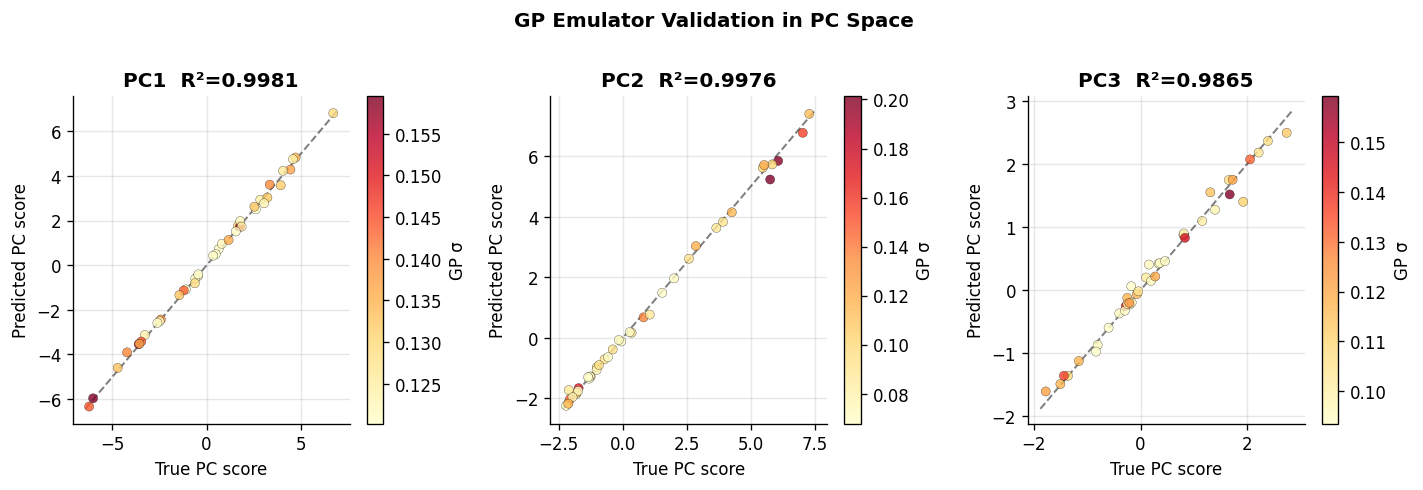

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.4  PC-space validation: one GP's predictions
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_PC, figsize=(4*N_PC, 4))
if N_PC == 1:
    axes = [axes]

for pc_idx, (gp, ax) in enumerate(zip(gps, axes)):
    z_true = Z_val[:, pc_idx]
    z_pred, z_std = gp.predict(X_val, return_std=True)
    r2 = r2_score(z_true, z_pred)

    lo = min(z_true.min(), z_pred.min()) - 0.1
    hi = max(z_true.max(), z_pred.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5)
    sc = ax.scatter(z_true, z_pred, c=z_std, cmap='YlOrRd', s=30, alpha=0.8,
                   edgecolors='k', lw=0.2, zorder=3)
    plt.colorbar(sc, ax=ax, label='GP σ')
    ax.set_xlabel('True PC score'); ax.set_ylabel('Predicted PC score')
    ax.set_title(f'PC{pc_idx+1}  R²={r2:.4f}', fontweight='bold')

plt.suptitle('GP Emulator Validation in PC Space', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part VI — Interactive: Emulator Predictions vs. Parameters

Explore how the observables change as we vary each physics parameter.

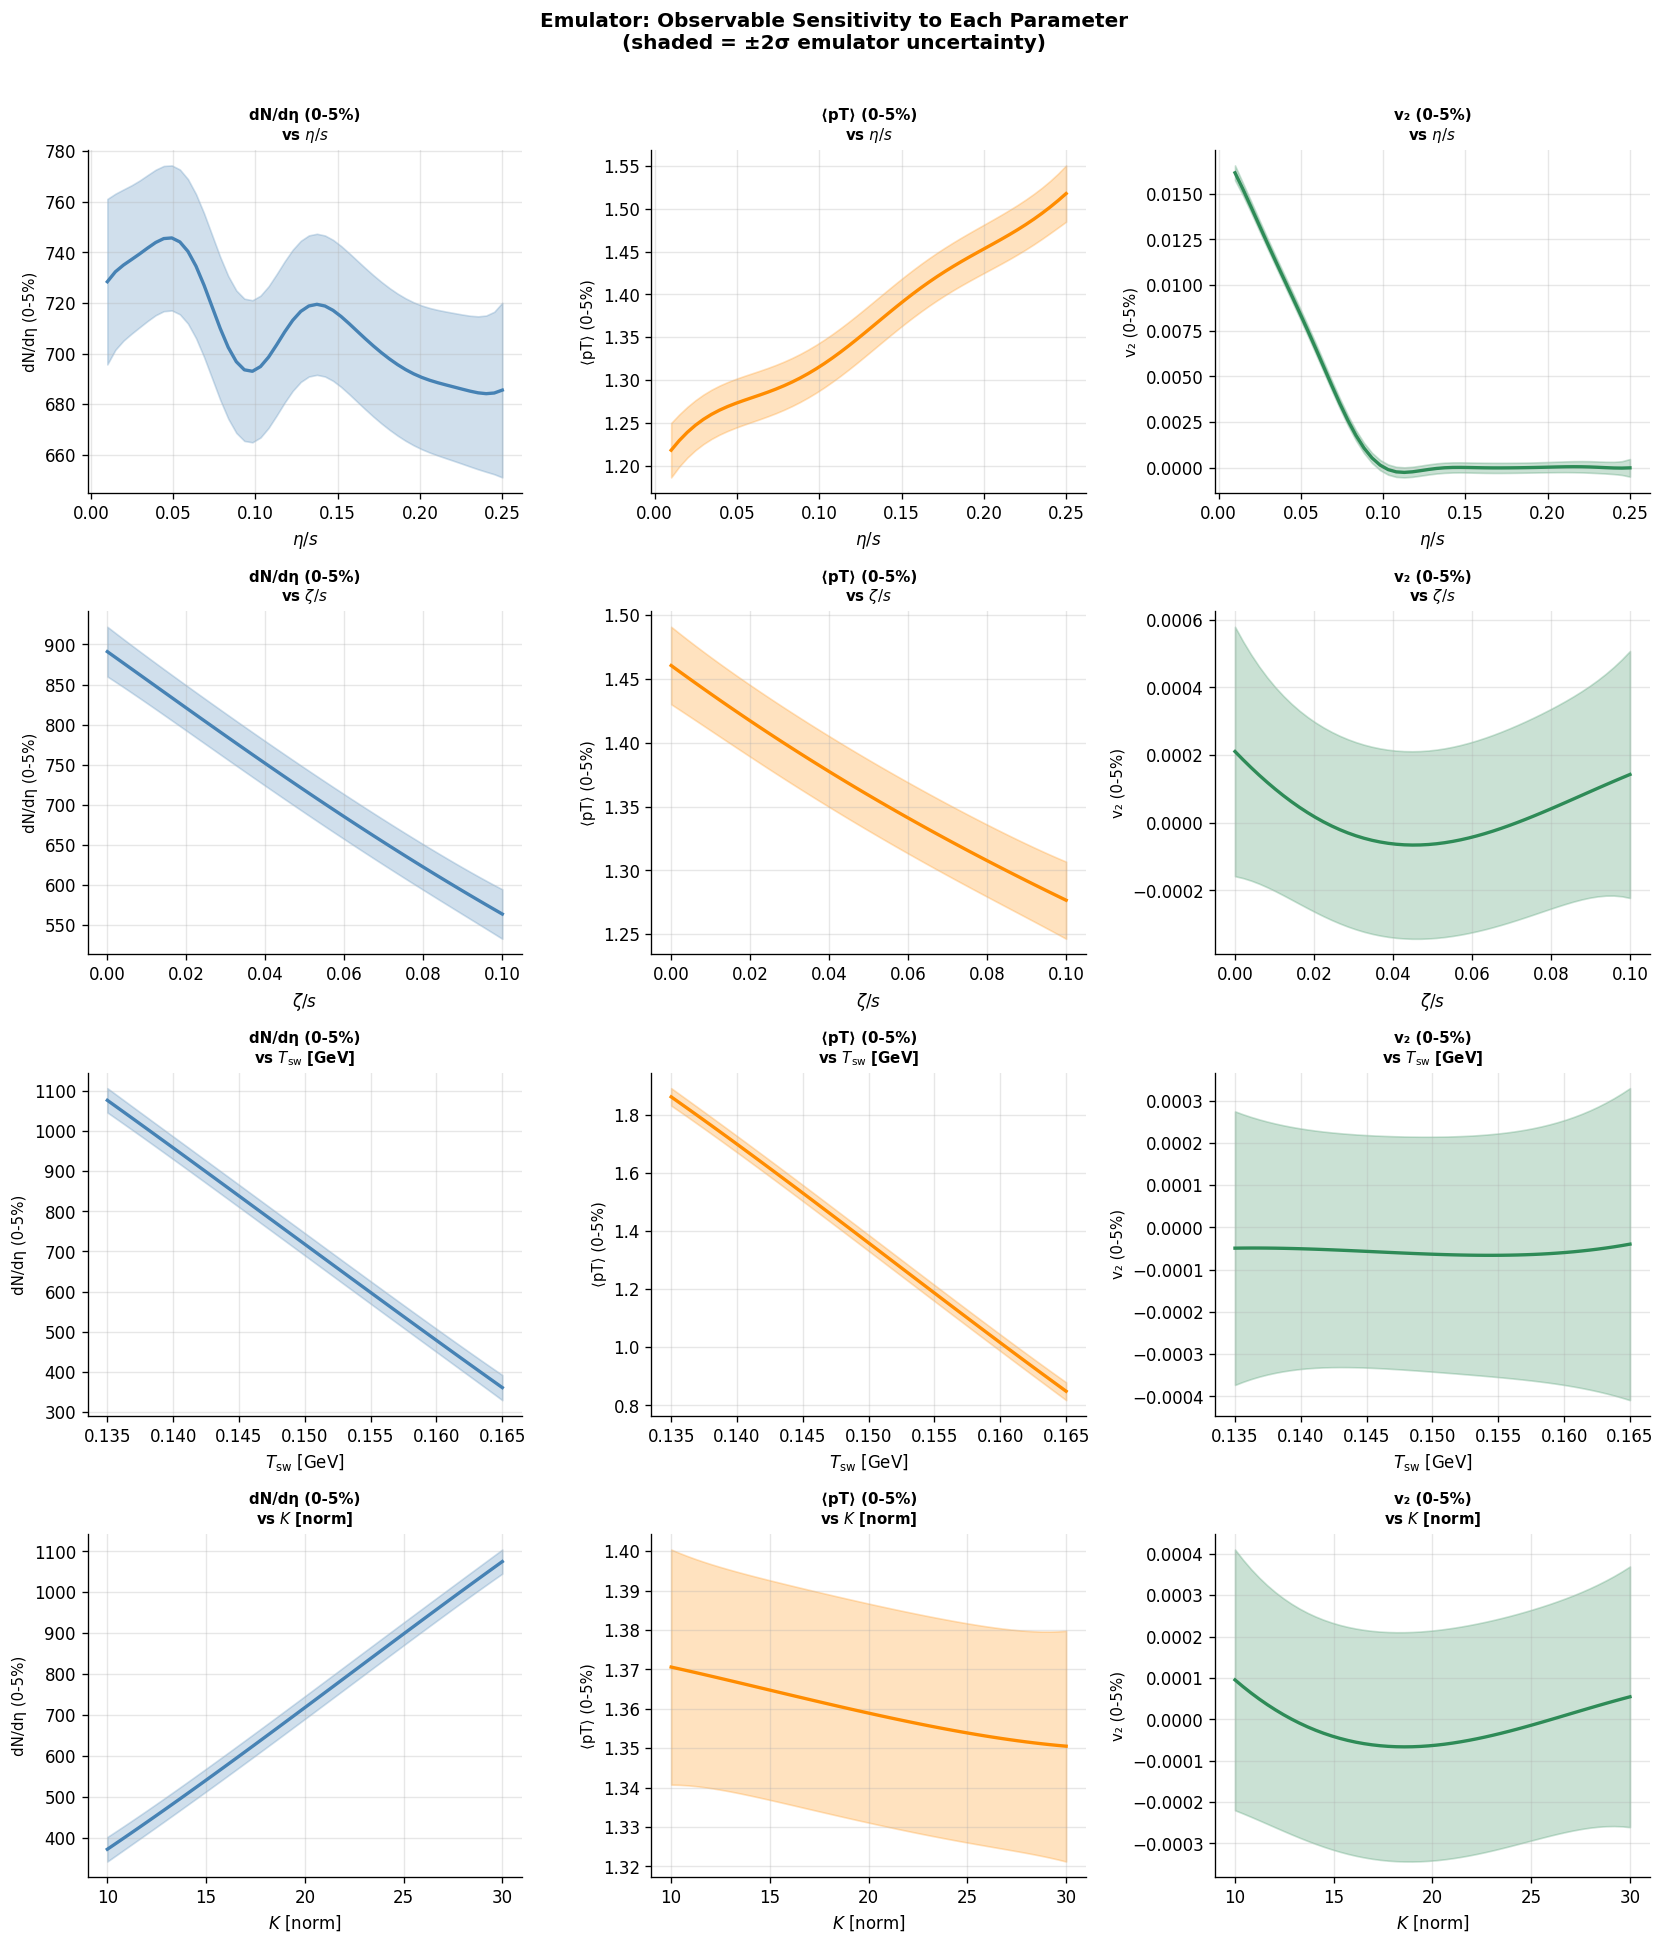

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.1  1D slices through parameter space
# ─────────────────────────────────────────────────────────────────────────────
# Fix all parameters at their midpoints, vary one at a time
param_mid = np.mean(np.array(param_bounds), axis=1)
param_range_steps = 50

fig, axes = plt.subplots(len(param_names), 3, figsize=(14, 4*len(param_names)),
                         squeeze=False)

obs_to_plot = [
    (0,  'dN/dη (0-5%)',   'steelblue'),
    (1,  '⟨pT⟩ (0-5%)',    'darkorange'),
    (2,  'v₂ (0-5%)',       'seagreen'),
]

for p_idx, p_name in enumerate(param_names):
    # Vary parameter p_idx; fix others at midpoint
    p_lo, p_hi = param_bounds[p_idx]
    p_vals = np.linspace(p_lo, p_hi, param_range_steps)

    X_slice = np.tile(param_mid, (param_range_steps, 1))
    X_slice[:, p_idx] = p_vals

    Y_slice, Y_slice_std = emulate(X_slice, gps, scaler, pca, N_PC, return_std=True)

    for ax, (obs_idx, obs_name, color) in zip(axes[p_idx], obs_to_plot):
        y_m = Y_slice[:, obs_idx]
        y_s = Y_slice_std[:, obs_idx]
        ax.plot(p_vals, y_m, color=color, lw=2)
        ax.fill_between(p_vals, y_m - 2*y_s, y_m + 2*y_s,
                        alpha=0.25, color=color)
        ax.set_xlabel(p_name, fontsize=10)
        ax.set_ylabel(obs_name, fontsize=9)
        ax.set_title(f'{obs_name}\nvs {p_name}', fontsize=9, fontweight='bold')

plt.suptitle('Emulator: Observable Sensitivity to Each Parameter\n'
             '(shaded = ±2σ emulator uncertainty)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

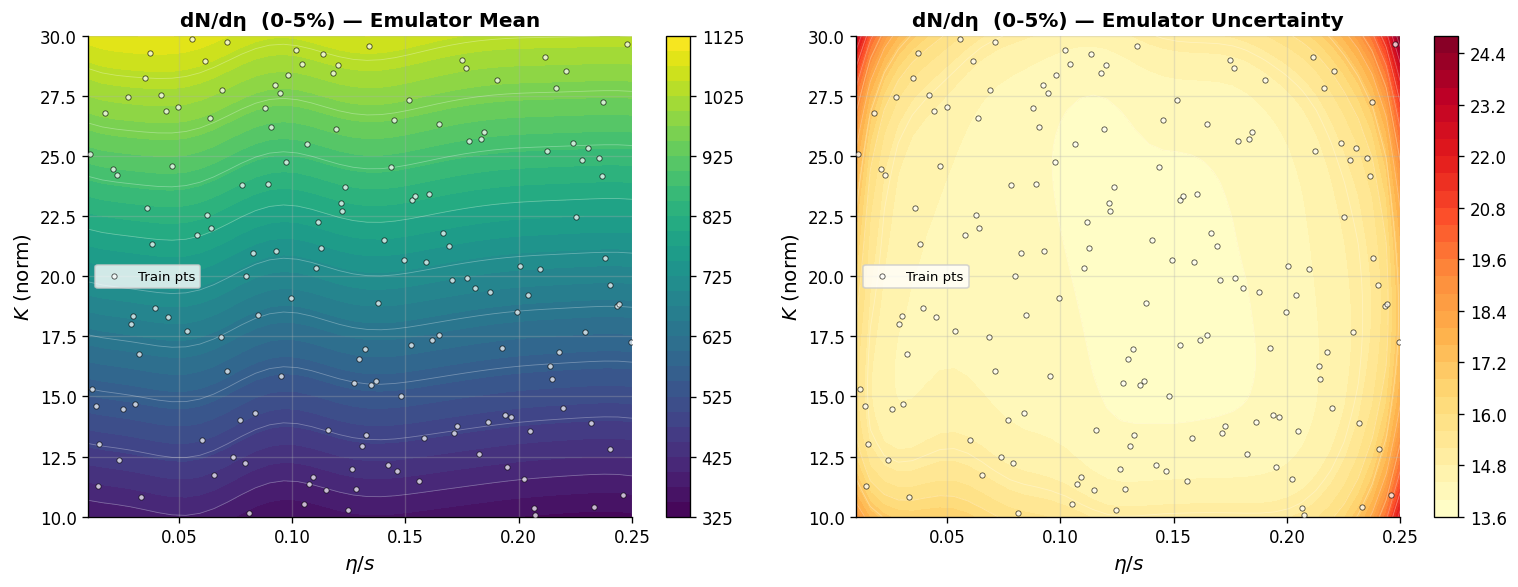

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.2  2D emulator map: η/s vs K for dN/dη
# ─────────────────────────────────────────────────────────────────────────────
n_grid = 40
eta_s_grid = np.linspace(*param_bounds[0], n_grid)
K_grid     = np.linspace(*param_bounds[3], n_grid)
ETA, KK    = np.meshgrid(eta_s_grid, K_grid)

X_grid = np.column_stack([
    ETA.ravel(),
    np.full(n_grid**2, param_mid[1]),  # fix zeta_s
    np.full(n_grid**2, param_mid[2]),  # fix T_sw
    KK.ravel(),
])

Y_grid, Y_grid_std = emulate(X_grid, gps, scaler, pca, N_PC, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (obs_idx, title, cmap) in zip(axes, [
    (0, 'dN/dη  (0-5%) — Emulator Mean',       'viridis'),
    (0, 'dN/dη  (0-5%) — Emulator Uncertainty', 'YlOrRd'),
]):
    if 'Uncertainty' in title:
        Z_map = Y_grid_std[:, obs_idx].reshape(n_grid, n_grid)
    else:
        Z_map = Y_grid[:, obs_idx].reshape(n_grid, n_grid)

    im = ax.contourf(ETA, KK, Z_map, levels=30, cmap=cmap)
    ax.contour(ETA, KK, Z_map, levels=10, colors='white', alpha=0.3, linewidths=0.5)
    plt.colorbar(im, ax=ax)

    # Training points projected
    ax.scatter(X_train[:, 0], X_train[:, 3], s=10, c='white',
               edgecolors='k', lw=0.5, zorder=5, alpha=0.7, label='Train pts')
    ax.set_xlabel(r'$\eta/s$', fontsize=12)
    ax.set_ylabel(r'$K$ (norm)', fontsize=12)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part VII — Exercises & Extensions

### 🧠 Exercise 7.1 — Effect of design size
> Rebuild the emulator with N_DESIGN = 50, 100, 200. How does the R² and calibration change?

N_design=  50: n_PC=3, median R²=-0.0068
N_design= 100: n_PC=3, median R²=-0.0558
N_design= 200: n_PC=3, median R²=0.9856


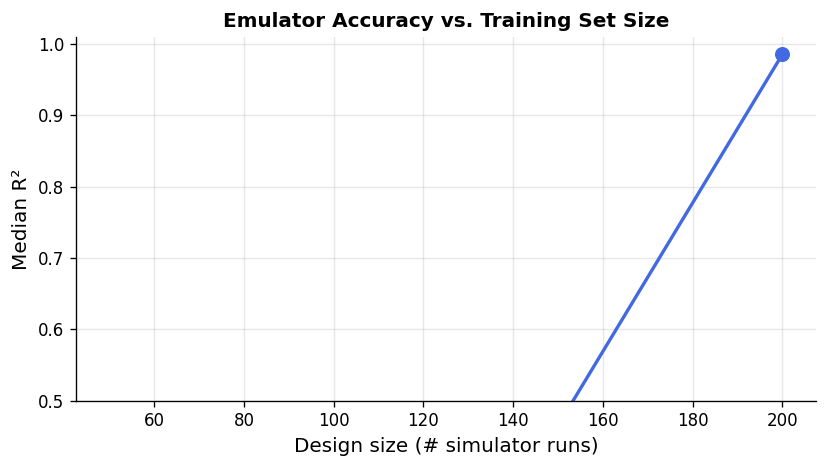

In [23]:
# ── Exercise 7.1: Design size study ──────────────────────────────────────────
design_sizes = [50, 100, 200]
r2_by_size = {}

for n_design in design_sizes:
    X_d = latin_hypercube(n_design, 4, param_bounds, seed=1)
    Y_d = simulate_heavy_ion(X_d, noise_level=0.025, seed=1)

    X_tr, X_vl, Y_tr, Y_vl = train_test_split(X_d, Y_d, test_size=0.2, random_state=0)

    sc_d   = StandardScaler().fit(Y_tr)
    pca_d  = PCA().fit(sc_d.transform(Y_tr))
    n_pc_d = np.searchsorted(np.cumsum(pca_d.explained_variance_ratio_), 0.99) + 1
    Z_tr_d = pca_d.transform(sc_d.transform(Y_tr))[:, :n_pc_d]

    gps_d = []
    for i in range(n_pc_d):
        gp = GaussianProcessRegressor(
            kernel=C(1.0)*RBF(np.ones(4))+WhiteKernel(1e-3),
            normalize_y=True, n_restarts_optimizer=3
        ).fit(X_tr, Z_tr_d[:, i])
        gps_d.append(gp)

    Y_pred_d = emulate(X_vl, gps_d, sc_d, pca_d, n_pc_d)
    r2_by_size[n_design] = np.median([r2_score(Y_vl[:,i], Y_pred_d[:,i])
                                       for i in range(Y_vl.shape[1])])
    print(f'N_design={n_design:4d}: n_PC={n_pc_d}, median R²={r2_by_size[n_design]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(design_sizes, [r2_by_size[n] for n in design_sizes], 'o-',
        color='royalblue', lw=2, markersize=8)
ax.set_xlabel('Design size (# simulator runs)', fontsize=12)
ax.set_ylabel('Median R²', fontsize=12)
ax.set_title('Emulator Accuracy vs. Training Set Size', fontweight='bold')
ax.set_ylim(0.5, 1.01)
plt.tight_layout()
plt.show()

### 🧠 Exercise 7.2 — Leave-one-out cross-validation

Computing LOO-CV for PC1 emulator...


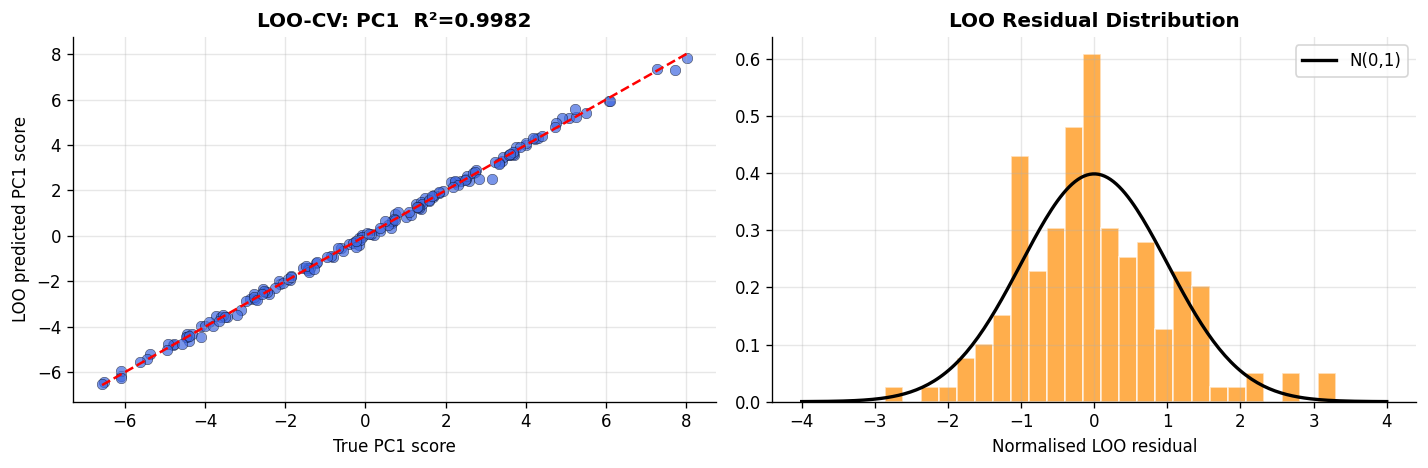

In [24]:
# ── Exercise 7.2: Leave-One-Out cross-validation for the 1D GP ───────────────
# LOO-CV is fast for GPs: the leave-one-out prediction can be computed
# analytically from the full GP.

from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm as normal_dist

loo_preds = np.zeros(len(X_train))
loo_stds  = np.zeros(len(X_train))

# Use PC1 GP
gp_loo = gps[0]

print('Computing LOO-CV for PC1 emulator...')
for i, (train_idx, test_idx) in enumerate(LeaveOneOut().split(X_train)):
    gp_tmp = GaussianProcessRegressor(
        kernel=gp_loo.kernel_,   # use already-optimised hyperparameters
        normalize_y=True, optimizer=None  # no re-optimisation for speed
    ).fit(X_train[train_idx], Z_train[train_idx, 0])
    mu, s = gp_tmp.predict(X_train[test_idx], return_std=True)
    loo_preds[i] = mu[0]; loo_stds[i] = s[0]

loo_resid = (Z_train[:, 0] - loo_preds) / (loo_stds + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(Z_train[:, 0], loo_preds, s=40, alpha=0.7, color='royalblue',
           edgecolors='k', lw=0.3)
lo_v = min(Z_train[:, 0].min(), loo_preds.min())
hi_v = max(Z_train[:, 0].max(), loo_preds.max())
ax.plot([lo_v,hi_v],[lo_v,hi_v],'r--',lw=1.5)
ax.set_xlabel('True PC1 score'); ax.set_ylabel('LOO predicted PC1 score')
ax.set_title(f'LOO-CV: PC1  R²={r2_score(Z_train[:,0], loo_preds):.4f}', fontweight='bold')

ax = axes[1]
ax.hist(loo_resid, bins=25, density=True, color='darkorange', alpha=0.7, edgecolor='white')
x_g = np.linspace(-4, 4, 200)
ax.plot(x_g, np.exp(-0.5*x_g**2)/np.sqrt(2*np.pi), 'k-', lw=2, label='N(0,1)')
ax.set_xlabel('Normalised LOO residual')
ax.set_title('LOO Residual Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### 🧠 Exercise 7.3 — Sensitivity analysis (Sobol-like)

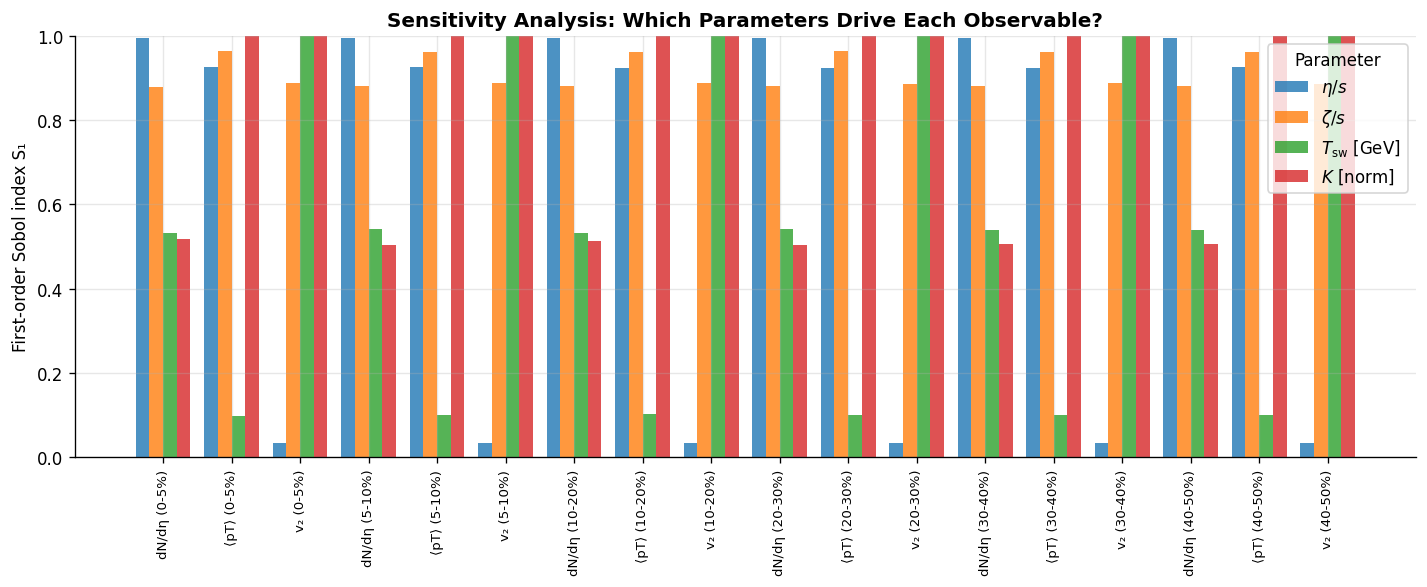


Dominant parameter per observable:
  dN/dη (0-5%)             : $\eta/s$  (S₁=0.995)
  ⟨pT⟩ (0-5%)              : $K$ [norm]  (S₁=1.000)
  v₂ (0-5%)                : $T_{\rm sw}$ [GeV]  (S₁=1.000)
  dN/dη (5-10%)            : $\eta/s$  (S₁=0.996)
  ⟨pT⟩ (5-10%)             : $K$ [norm]  (S₁=1.000)
  v₂ (5-10%)               : $T_{\rm sw}$ [GeV]  (S₁=1.000)
  dN/dη (10-20%)           : $\eta/s$  (S₁=0.996)
  ⟨pT⟩ (10-20%)            : $K$ [norm]  (S₁=1.000)
  v₂ (10-20%)              : $T_{\rm sw}$ [GeV]  (S₁=1.000)
  dN/dη (20-30%)           : $\eta/s$  (S₁=0.996)
  ⟨pT⟩ (20-30%)            : $K$ [norm]  (S₁=1.000)
  v₂ (20-30%)              : $T_{\rm sw}$ [GeV]  (S₁=1.000)
  dN/dη (30-40%)           : $\eta/s$  (S₁=0.996)
  ⟨pT⟩ (30-40%)            : $K$ [norm]  (S₁=1.000)
  v₂ (30-40%)              : $T_{\rm sw}$ [GeV]  (S₁=1.000)
  dN/dη (40-50%)           : $\eta/s$  (S₁=0.996)
  ⟨pT⟩ (40-50%)            : $K$ [norm]  (S₁=1.000)
  v₂ (40-50%)              : $T_{\rm sw}$ [GeV]  (S₁

In [25]:
# ── Exercise 7.3: Variance-based sensitivity using the emulator ───────────────
# Monte Carlo estimate of total variance and first-order Sobol indices
# Sᵢ = Var[E[Y|Xᵢ]] / Var[Y]

N_MC = 2000
X_mc = latin_hypercube(N_MC, 4, param_bounds, seed=99)
Y_mc = emulate(X_mc, gps, scaler, pca, N_PC)

total_var = Y_mc.var(axis=0)   # shape (n_obs,)

sobol_first = np.zeros((4, Y_mc.shape[1]))

for p_idx in range(4):
    # Resample all parameters except p_idx
    X_resampled = X_mc.copy()
    X_resampled[:, p_idx] = latin_hypercube(N_MC, 1,
                                             [param_bounds[p_idx]], seed=p_idx*100)[:, 0]
    Y_rs = emulate(X_resampled, gps, scaler, pca, N_PC)
    # Var_p = variance when holding p fixed (conditioned on p_idx)
    cond_var = ((Y_mc - Y_rs)**2 / 2).mean(axis=0)
    sobol_first[p_idx] = np.clip(1 - cond_var / (total_var + 1e-20), 0, 1)

# Plot Sobol indices for key observables
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(obs_labels))
width = 0.2
colors_s = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for p_idx, (p_name, color) in enumerate(zip(param_names, colors_s)):
    ax.bar(x_pos + p_idx*width, sobol_first[p_idx], width,
           label=p_name, color=color, alpha=0.8)

ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(obs_labels, rotation=90, fontsize=8)
ax.set_ylabel('First-order Sobol index S₁')
ax.set_title('Sensitivity Analysis: Which Parameters Drive Each Observable?',
             fontweight='bold')
ax.legend(title='Parameter', loc='upper right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('\nDominant parameter per observable:')
for i, lbl in enumerate(obs_labels):
    dom = np.argmax(sobol_first[:, i])
    print(f'  {lbl:25s}: {param_names[dom]}  (S₁={sobol_first[dom, i]:.3f})')

---
## Summary & Takeaways

| Step | What we did | Why |
|------|-------------|-----|
| **Standardize** | Subtract mean, divide by std | GP kernel treats dimensions equally |
| **PCA** | Compress 18 corr. observables → N_PC independent scores | Simpler, cheaper, decorrelated GPs |
| **GP per PC** | Fit one GP with ARD-RBF kernel to each PC score | Captures non-linear parameter dependence + uncertainty |
| **Reconstruct** | Inverse PCA + inverse scaler | Get predictions in original observable units |
| **Validate** | R², pred-vs-true scatter, calibration | Check emulator is accurate AND well-calibrated |

**Key equations:**

$$U(x_T) = \frac{\langle p_T \rangle}{N}\frac{dN}{dp_T} \qquad \text{(just a reminder from physics context!)}$$

$$\text{Emulator}: \quad \mathbf{X} \xrightarrow{\text{GP}_i} \hat{Z}_i \pm \sigma_i \xrightarrow{\text{PCA}^{-1}} \hat{\mathbf{Y}} \pm \boldsymbol{\sigma}_Y$$

$$R^2 = 1 - \frac{\sum(y_\text{true} - y_\text{pred})^2}{\sum(y_\text{true} - \bar{y})^2}$$

---
### References
- [JETSCAPE Summer School 2021 notebook](https://github.com/JETSCAPE/SummerSchool2021/blob/master/Jul28_29_BayesianSoftExample/BayesianParameterEstimationForRelativisticHeavyIonPhysics-JS21.ipynb)
- Bernhard et al., *Phys. Rev. C* **91**, 054910 (2015) — GP emulators for heavy-ion physics
- Rasmussen & Williams, *Gaussian Processes for Machine Learning* (2006) — [free PDF](http://www.gaussianprocess.org/gpml/)
- Saltelli et al., *Sensitivity Analysis in Practice* (2004) — Sobol sensitivity indices